<a href="https://www.kaggle.com/code/nahuelfuentes/rag-tutor-qa?scriptVersionId=317735012" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RAG Tutor QA

RAG implemented chatbot that allows a user to specify their domain via documents and use it as a knowledge database to answer questions and avoid hallucinations

# Imports

In [1]:
!pip install -qq langchain_community
!pip install -qq langchain_text_splitters
!pip install -qq langchain_community
!pip install -qq qdrant_client
!pip install -qq langchain_qdrant
!pip install -qq langchain_core
!pip install -qq langchain-google-genai
!pip install -qq PyMuPDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 51.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
gcsfs 2025.3.0 require

In [2]:
import os
from sentence_transformers import SentenceTransformer

from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

## Documents

### Document loading

Using notebook input

In [3]:
# We use PyMuPDF for handling special characters on documents
loader = DirectoryLoader('/kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria', glob="**/*.pdf", loader_cls = PyMuPDFLoader)
pages = loader.load()

print(f"Total pages: {len(pages)}")

unique_files = set()
for page in pages:
    source = page.metadata.get('source')
    unique_files.add(source)

print(f"Total files: {len(unique_files)}")

for file in unique_files:
    print(f"- {file}")

Total pages: 67
Total files: 20
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Derivadas parciales y Difereciabilidad/Diferenciabilidad1.pdf
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Interpretación Geométrica.pdf
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Limite doble, direccional, infinitesimos. Continuidad/LimitesDireccionales.pdf
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Limite doble, direccional, infinitesimos. Continuidad/LDenPolares.pdf
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Topologia, funciones de dos y mas variables/CurvasySupde nivel.pdf
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Superficies y regiones en el espacio/Superficies_Rev.pdf
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Limite doble, direccional, infinitesimos. Continuidad/Infinitesimos.pdf
- /kaggle/input/datasets/nahuelfuentes/am-2-teoria/Teoria/Derivadas parciales y Difereciabilidad/Diferenciabilidad2.pdf
- /ka

### Document cleaning

We perfom a rough EDA to check if the pages are correctly display or there are any incorrectly formatted PDFs, blank pages, cover pages, etc.

In [4]:
from collections import Counter

page_contents = [page.page_content for page in pages]

page_counts = Counter(page_contents)

duplicates = {content: count for content, count in page_counts.items() if count > 1}

print(f"Total pages: {len(pages)}")
print(f"Unique pages: {len(page_counts)}")
print(f"Pages with duplicates: {len(duplicates)}")
print(f"\n=== Pages Documents ===")


# We list what are the repeating patterns
for content, count in sorted(duplicates.items(), key=lambda x: x[1], reverse=True):
    print(f"\nRepeated {count} times:")
    print(f"  Content preview: {content[:100]}...")
    print(f"  Full length: {len(content)} chars")


Total pages: 67
Unique pages: 67
Pages with duplicates: 0

=== Pages Documents ===


Based on each dataset we may or may not have a repeating patterns that we should take care of before continuing.

### Document batching and embedding

The loaded documents are in spanish and present an error where accent are so we should clean them before using it 

Splitting

In [5]:
import unicodedata

def clean_text(text: str) -> str:
    replacements = {
        '\u00b4a': 'á', '\u00b4e': 'é', '\u00b4i': 'í',
        '\u00b4o': 'ó', '\u00b4u': 'ú',
        '\u00b4A': 'Á', '\u00b4E': 'É', '\u00b4I': 'Í',
        '\u00b4O': 'Ó', '\u00b4U': 'Ú',
        '\u00b4on': 'ión', '\u00b4On': 'Ión',
        '~n': 'ñ', '~N': 'Ñ',
    }
    for broken, fixed in replacements.items():
        text = text.replace(broken, fixed)
    return text

# Apply after loading
for doc in pages:
    doc.page_content = clean_text(doc.page_content)

# Verify it worked
print(pages[1].page_content[:200])

Análisis matemático II
Profesor: Graciela Paolini
Derivada de funciones compuestas. Regla de la cadena.
Sea f(x, y) una función diferenciable en P0 = (x0, y0), tal que



x = x(t)
y = y(t)
x(t), y(


In [6]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ".", "!", "¡","¿", "?", ",", " "]
)
splits = text_splitter.split_documents(pages)

EDA in chunks

In [7]:
import pandas as pd

df = pd.DataFrame([
    {
        'chunk_id': i,
        'content': split.page_content,
        'source': split.metadata.get('source'),
        'page': split.metadata.get('page', 'N/A'),
        'char_length': len(split.page_content),
        'word_count': len(split.page_content.split()),
    }
    for i, split in enumerate(splits)
])

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

print(df.describe())

# Quick sanity check
print("=== QUICK VALIDATION ===")
print(f"Avg chunk size: {df['char_length'].mean():.0f} chars (should be ~1000)")
print(f"Min chunk size: {df['char_length'].min()} (too small?)")
print(f"Max chunk size: {df['char_length'].max()}")


   chunk_id                                            content  \
0         0  Análisis matemático II\nProfesor: Graciela Pao...   
1         1  f(x, y) una función diferenciable en P0 = (x0,...   
2         2  Análisis matemático II\nProfesor: Graciela Pao...   
3         3  Escribimos C en forma paramétrica: C =\n\n\n...   
4         4  Análisis matemático II\nProfesor: Graciela Pao...   

                                              source  page  char_length  \
0  /kaggle/input/datasets/nahuelfuentes/am-2-teor...     0          991   
1  /kaggle/input/datasets/nahuelfuentes/am-2-teor...     0          287   
2  /kaggle/input/datasets/nahuelfuentes/am-2-teor...     1          991   
3  /kaggle/input/datasets/nahuelfuentes/am-2-teor...     1          356   
4  /kaggle/input/datasets/nahuelfuentes/am-2-teor...     2          993   

   word_count  
0         186  
1          66  
2         207  
3          72  
4         200  

Shape: (113, 6)

Columns: ['chunk_id', 'content', 'sour

A visualization on the quality of our splitting

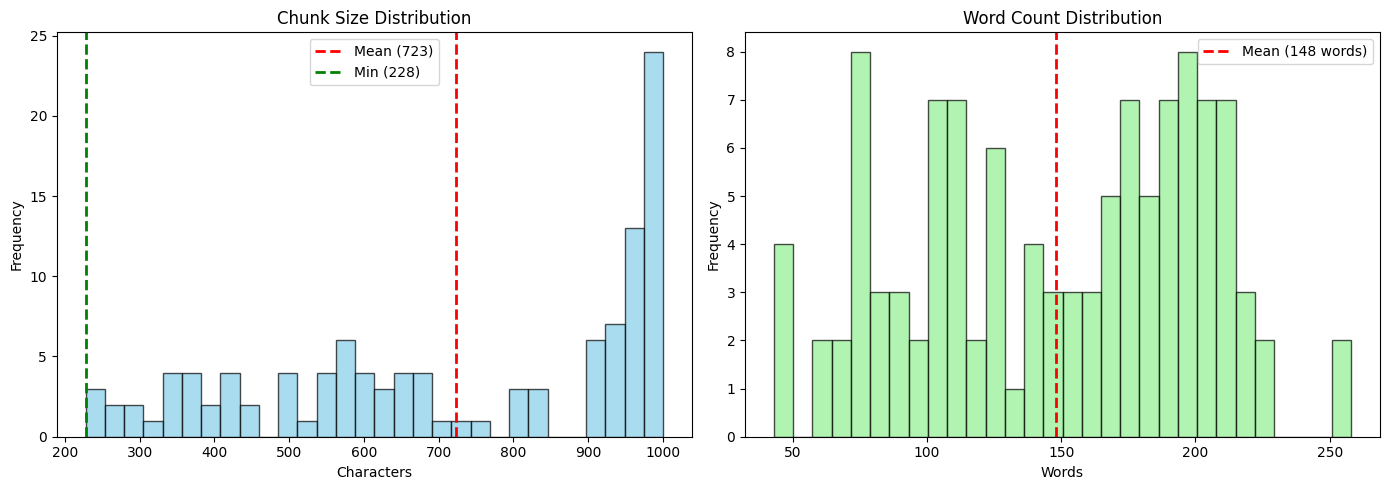

In [8]:
import matplotlib.pyplot as plt

# Calculate statistics
cl_mean_val = df['char_length'].mean()      
cl_min_val = df['char_length'].min()        
cl_max_val = df['char_length'].max()       

wc_mean_val = df['word_count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df['char_length'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(cl_mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({cl_mean_val:.0f})')
axes[0].axvline(cl_min_val, color='green', linestyle='--', linewidth=2, label=f'Min ({cl_min_val})')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chunk Size Distribution')
axes[0].legend()

# Word count
axes[1].hist(df['word_count'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].axvline(wc_mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean ({wc_mean_val:.0f} words)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Word Count Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

As a rule of thumb we follow that 4 characters aproximates to 1 token,we display them and choose the embedding accordingly, not only choosing an embedding that allows for the estimated tokens on a chunk but give them a bit of breathing space to the max tokens

In [9]:
safety_margin = 1.2
overlap = 200 # Defined at text splitting

estimated_tokens = ((cl_mean_val + overlap) / 4) * safety_margin
print(f"Estimated tokens per chunk: {estimated_tokens:.0f}")

Estimated tokens per chunk: 277


Embedding according to max tokens and multilingual for our case

In [10]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-large",
    model_kwargs={"device": "cuda"},
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 16
    }
)

/tmp/ipykernel_57/975910657.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

# Vector DB

## Creating and storing our RAG documents

We use Qdrant as our similarity searcher and responsible for our vector clustering

In [11]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

# We store every document and vector DB on cloud 
client = QdrantClient(":memory:")

client.create_collection(
    collection_name="rag_docs",
    vectors_config=VectorParams(
        size=1024,
        distance=Distance.COSINE # Based on dot product and Theory about semantic represtation
    )
)

vectorstore = QdrantVectorStore(
    client=client,
    collection_name="rag_docs",
    embedding=embeddings
)

vectorstore.add_documents(splits)

['526d9ace17b3448298454853839718de',
 'e9991f04f0b94ce9827b65a09850ee64',
 '6c8d5921c50e48b6a8e43b66b7ee4098',
 '178c12fff69841ceb7af7722ea728ff7',
 '6beaafc2af6e48febbece58b79b98404',
 '017a5e0056bf45b49d0fb1bf449edfe8',
 'a9d3a34d4db14d15898a3745d0aa57dc',
 '02e174214e904a1e9049dedb4a2b2eb3',
 '74992abf80984d7fbbca0e3dd44c1d8f',
 '58f7e9bc3b944a279d58f6a3f96a9a72',
 'd8bafbbc591643b9a4fc2fb1c12c01d2',
 'b226e69e3fdd4027a120c44b139376ed',
 'b1b686a622ec4b1985aae7b4f817e705',
 'd29aaf902495477c968470e9b1b904e7',
 '26800342bf294334acc2ab5d0d6e00af',
 '4f8fc29862da47f2b23c4b9d378db194',
 '3573967d781d4ec69261a2eb75b815d2',
 '174b640748414cfaa261d01a99e5e8a4',
 'e278b7a3174c4911824c0035b45ee805',
 '44fe2230cfb04f888af235a2a576a75d',
 '2bbbe20e52164aa28a4b2f1c3c6dd734',
 '29ca1df3d4ba4dbe893fc90f109dfcb8',
 '441c57f17f1e4e44abe5432b14afd001',
 '3d5a668e5d6341d8a75b2bb5430a6f01',
 '5506a0bd72fb4f97b186d54e6ae01110',
 '0ead542477504050aa118f69a5bc7c24',
 'c2f00b7566124c15bff78a5cc7362d3f',
 

## Retriver

We need a way to retrive, based on a vector query, the similarity of the vectors in the knowledge database

In [12]:
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}  # Number of top relevant chunks
)

As a test

In [13]:
docs = retriever.invoke("Como se define la derivada parcial")
for doc in docs:
    print(doc.page_content[:200])
    print("---")

ﬁjo el valor de x = x0 y se calcula la derivada respecto de la variable y como función de una variable.
Interpretación geométrica: en el video.
Observaciones:
1. Vamos a decir que una función f(x, y) 
---
que notamos fx(P0) o ∂f
∂x (P0) es el valor del siguiente l´ımite ﬁnito, si existe:
L = l´ım
∆x→0
f(x0 + ∆x, y0) −f(x0, y0)
∆x
Observación: Para calcular la derivada parcial respecto de x en el punto 
---
superiores.
NOTACIÓN: Vamos a decir que una función f(x, y) es:
de clase C1 y notamos f ∈C1 en un punto P0 si f(x, y) es continua en P0 y sus derivadas
primeras son continuas en P0.
de clase C2 y nota
---
gy es cociente de funciones continuas, con denominador distinto de cero en D.
gx es suma de funciones continuas en el conjunto D
Respuesta: La función g(x, y) = x2 + ln (5x + y) es diferenciable en el
---
Veamos que, por ejemplo, la derivada parcial de f1 respecto de x no es continua en P0 = (0, 0):
Cálculo auxiliar:
(f1)x (x, y) =



2xsen

1
x2+y2

−
2x
x2+y2cos

1
x2+y2

(

# Prompt Template

We create the template that will be followed for every query to the LLM using the context retrieved from the knowledge database

In [14]:
from langchain_core.prompts import PromptTemplate

template = """
You are a helpful assistant specialized in mathematics and engineering.
The context may contain mathematical formulas with imperfect formatting — interpret them carefully.
Answer using ONLY the context below. If the answer is not in the context, say "I don't know / No lo sé".
Answer in the SAME LANGUAGE the question was asked in.

Context:
{context}

Question:
{question}

Answer:"""

prompt = PromptTemplate(
    input_variables = ["context","question"],
    template = template
)

# LLM

We use a Gemini as our LLM as a testing ground

In [18]:
!pip install -qq langchain_groq

from kaggle_secrets import UserSecretsClient
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

secret = UserSecretsClient()
# GEMINI_API_KEY = secret.get_secret("GEMINI_API_KEY")

# llm = ChatGoogleGenerativeAI(
#     model="gemma-4-26b-a4b-it",
#     google_api_key=GEMINI_API_KEY
# )

GROQ_API_KEY = secret.get_secret("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY
)

We create the rag chained based on our documents, prompt template and LLM that we defined

In [19]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | prompt
    | llm
    | StrOutputParser()
)

# Usage

We still need to add memory to this conversation but for testing purposes we could try a simple query

In [20]:
from IPython.display import display, Markdown

question = ("Que son las derivadas de segundo orden")  
display(Markdown(f"**Pregunta:** {question}"))
answer = rag_chain.invoke(question)
display(Markdown(f"**Respuesta:** {answer}"))

**Pregunta:** Que son las derivadas de segundo orden

**Respuesta:** Las derivadas de segundo orden de una función f(x, y) son cuatro y se notan así:

1. fxx(x, y) = (fx)x (x, y)
2. fxy(x, y) = (fx)y (x, y)
3. fyx(x, y) = (fy)x (x, y)
4. fyy(x, y) = (fy)y (x, y)

Estas derivadas se obtienen derivando las derivadas parciales de primer orden de la función f(x, y) respecto de x e y.

We add memory to it using LangChain tools for keeping messages history in the session

In [21]:
from langchain_core.runnables import RunnableWithMessageHistory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_community.chat_message_histories import ChatMessageHistory
from operator import itemgetter

prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a helpful assistant specialized in mathematics and engineering.
The context may contain mathematical formulas with imperfect formatting — interpret them carefully.
Answer using ONLY the context below. If the answer is not in the context, say "I don't know / No lo sé".
Answer in the SAME LANGUAGE the question was asked in.

Context:
{context}"""),
    MessagesPlaceholder(variable_name="history"),  # ← conversation history
    ("human", "{question}")
])

store = {}
def get_session_history(session_id: str):
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]

rag_chain = (
    {
        "context": itemgetter("question") | retriever | format_docs,
        "question": itemgetter("question"),
        "history": itemgetter("history")
    }
    | prompt
    | llm
    | StrOutputParser()
)

chain_with_history = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key="question",
    history_messages_key="history"
)

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


Finally we have

In [22]:
SESSION_ID = "user_session"
print("Type 'salir' or 'exit' to stop\n")

while True:
    question = input("Pregunta: ")
    
    if question.lower() in ["salir", "exit", ""]:
        print("Fin de la sesión.")
        break
    
    answer = chain_with_history.invoke(
        {"question": question},
        config={"configurable": {"session_id": SESSION_ID}}
    )
    display(Markdown(f"**Respuesta:** {answer}"))
    print()


Type 'salir' or 'exit' to stop



Pregunta:  Hola como te llamas


**Respuesta:** 0
0
Entonces, podemos calcular el límite usando el teorema de L´opital.
Aplicando el teorema de Lopital, obtenemos:
∂f
∂x (x, y) = 
(2x+1)(y−1)−(2x+6)(y)
(2x+6)2+(y−1)2
∂f
∂y (x, y) = 
(x+6)(2y+1)−(x+3)(2y)
(2x+6)2+(y−1)2
Luego, reemplazando los valores (x, y) = (−3, 1) en las derivadas parciales, obtenemos:
∂f
∂x (−3, 1) = 0 y ∂f
∂y (−3, 1) = 3.
Por lo tanto, el límite es:
l´ım
(x,y)→(−3,1)
x y−x+3y−3
(x+3)2+(y−1)2
= 3
No lo sé.

Pregunta:  Como se definen las derivadas parciales


**Respuesta:** Según el contexto, las derivadas parciales se definen de la siguiente manera:

La derivada parcial respecto de x en el punto P0 = (x0, y0) de la función f(x, y), que se nota como fx(P0) o ∂f/∂x (P0), es el valor del siguiente límite finito, si existe:

L = lím (∆x→0) [f(x0 + ∆x, y0) - f(x0, y0)] / ∆x

Para calcular la derivada parcial respecto de x en el punto P0 = (x0, y0), se deja fijo el valor de y = y0 y se calcula la derivada respecto de la variable x como función de una variable.

De manera análoga, la derivada parcial respecto de y en el punto P0 = (x0, y0) de la función f(x, y), que se nota como fy(P0) o ∂f/∂y (P0), es el valor del siguiente límite finito, si existe:

L = lím (∆y→0) [f(x0, y0 + ∆y) - f(x0, y0)] / ∆y

Para calcular la derivada parcial respecto de y en el punto P0 = (x0, y0), se deja fijo el valor de x = x0 y se calcula la derivada respecto de la variable y como función de una variable.

Pregunta:  Que pregunta te hice previamente?


**Respuesta:** 0/0. Para resolverlo, se puede hacer un cambio de variables, como por ejemplo, u = x+3, v = y−1.
Entonces:
f(u, v) =
u(v+1)−(u−3)+(3v+3)
(u)2+(v)2
=
3u+v+3
u2+v2

No lo sé

Pregunta:  salir


Fin de la sesión.


# Metrics

 We use RAGAS to generate the performance's metrics of the RAG que just implemented to retrieve metrics such as *faithfullness* and *answer relevancy* 
 
(for calculating context precision we need references but as the RAG purpose is to have different documents we can't keep the same reference for different documents)

In [23]:
!pip install -qq ragas

from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset

ragas_llm = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

eval_questions = [
    "¿Qué es el límite direccional?",
    "¿Cómo se define la derivada parcial?",
    "¿Qué es la diferenciabilidad?",
    "¿Qué es la continuidad de una función?"
]

eval_data = {
    "question": [],
    "answer": [],
    "contexts": [],
}

for question in eval_questions:
    retrieved_docs = retriever.invoke(question)
    answer = rag_chain.invoke({
        "question":question,
        "history": [] # We keep the chat history empty for evaluation purposes
    })
    
    eval_data["question"].append(question)
    eval_data["answer"].append(answer)
    eval_data["contexts"].append([doc.page_content for doc in retrieved_docs])

dataset = Dataset.from_dict(eval_data)

results = evaluate(
    dataset=dataset,
    metrics=[faithfulness, answer_relevancy],
    llm=ragas_llm,
    embeddings=ragas_embeddings
)

print(results)
df_results = results.to_pandas()
df_results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 86.8 MB/s eta 0:00:00:00:0100:01


/usr/local/lib/python3.12/dist-packages/wrapt/importer.py:223: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  self.__wrapped__.exec_module(module)
/tmp/ipykernel_57/603322508.py:4: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_57/603322508.py:4: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import an

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


{'faithfulness': 0.8214, 'answer_relevancy': 0.9385}


,user_input,retrieved_contexts,response,faithfulness,answer_relevancy
0,¿Qué es el límite direccional?,[Análisis matemático II\nProfesor: Graciela Pa...,El límite direccional se refiere al límite de ...,1.000000,0.931390
1,¿Cómo se define la derivada parcial?,[ﬁjo el valor de x = x0 y se calcula la deriva...,La derivada parcial se define de la siguiente ...,0.857143,0.956295
2,¿Qué es la diferenciabilidad?,"[gy es cociente de funciones continuas, con de...",La diferenciabilidad se refiere a la propiedad...,0.714286,0.923096
3,¿Qué es la continuidad de una función?,[es continua en x = x0 entonces:\nl´ım\nx→x0 f...,La continuidad de una función se define como l...,0.714286,0.943250
